# Part 1: Data Engineering

In [1]:
import os
import time
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large

# --- LOCAL CONFIGURATION ---
BASE_PATH = './PlantVillage' 
TRAIN_DIR = f'{BASE_PATH}/train'
VAL_DIR = f'{BASE_PATH}/val'

IMAGE_SIZE = (128, 128)   # Reduced image size so your CPU processes fast
BATCH_SIZE = 32
LOCAL_EPOCHS = 3          # 3 epochs ensures it finishes in minutes, not hours

# Load a safe 10% sample of your local data for fast laptop training
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.10, subset="validation", seed=1337,
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, validation_split=0.20, subset="validation", seed=1337,
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)
test_ds = val_ds 
num_classes = len(train_ds.class_names)
print(f"\n✅ Dataset safely linked locally! Ready to train on {num_classes} classes.")

Found 43444 files belonging to 38 classes.
Using 4344 files for validation.
Found 10861 files belonging to 38 classes.
Using 2172 files for validation.

✅ Dataset safely linked locally! Ready to train on 38 classes.



🚀 Initializing ResNet50 Pipeline...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 113s 790ms/step - accuracy: 0.6796 - loss: 1.2573 - val_accuracy: 0.8343 - val_loss: 0.5799
Epoch 2/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 104s 766ms/step - accuracy: 0.9072 - loss: 0.3620 - val_accuracy: 0.8748 - val_loss: 0.4129
Epoch 3/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 117s 860ms/step - accuracy: 0.9505 - loss: 0.2172 - val_accuracy: 0.9033 - val_loss: 0.3398

==================== ResNet50 PERFORMANCE BREAKDOWN ====================
⏱️ Training Duration: 333.86 seconds


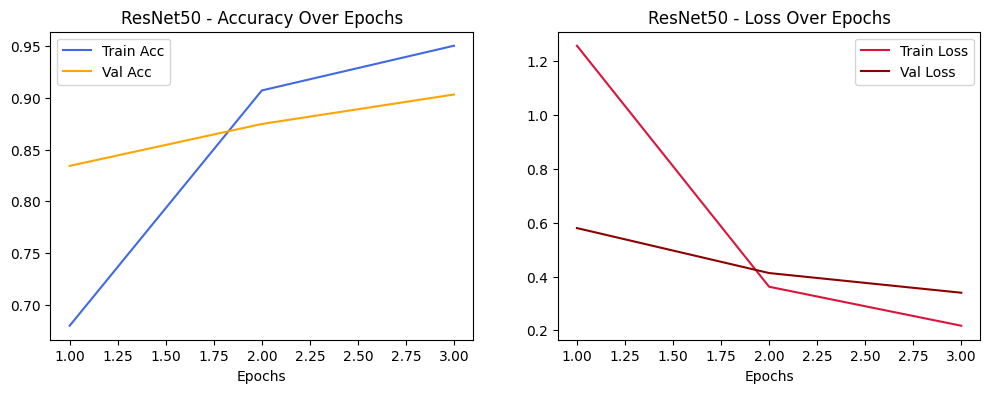

🎯 Final Evaluation Accuracy: 90.33%


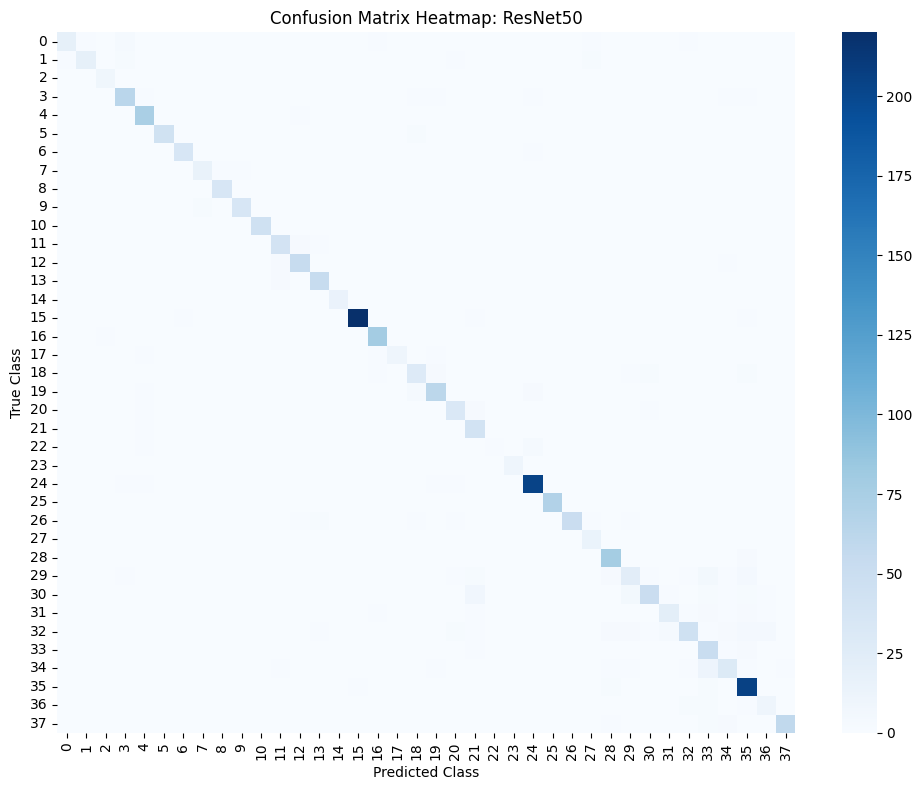

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.70      0.81        27
                                 Apple___Black_rot       0.95      0.76      0.84        25
                          Apple___Cedar_apple_rust       0.90      1.00      0.95         9
                                   Apple___healthy       0.89      0.91      0.90        69
                               Blueberry___healthy       0.91      0.99      0.95        75
          Cherry_(including_sour)___Powdery_mildew       1.00      0.96      0.98        45
                 Cherry_(including_sour)___healthy       0.97      0.97      0.97        37
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.89      0.89        18
                       Corn_(maize)___Common_rust_       0.97      1.00      0.99        36
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.95      0.

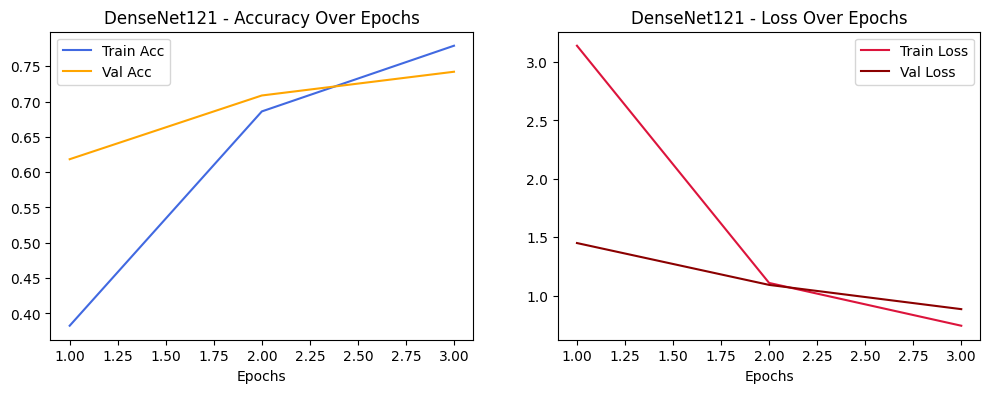

🎯 Final Evaluation Accuracy: 74.22%


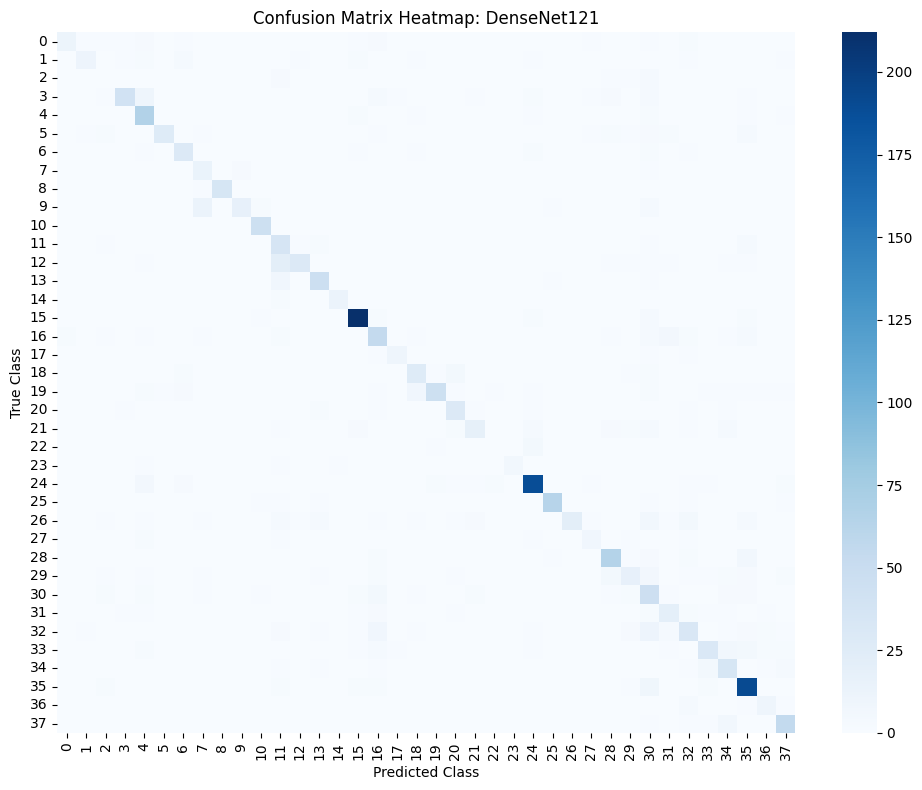

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.86      0.44      0.59        27
                                 Apple___Black_rot       0.79      0.44      0.56        25
                          Apple___Cedar_apple_rust       0.00      0.00      0.00         9
                                   Apple___healthy       0.91      0.59      0.72        69
                               Blueberry___healthy       0.65      0.89      0.75        75
          Cherry_(including_sour)___Powdery_mildew       0.96      0.60      0.74        45
                 Cherry_(including_sour)___healthy       0.69      0.78      0.73        37
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.42      0.78      0.55        18
                       Corn_(maize)___Common_rust_       1.00      0.97      0.99        36
               Corn_(maize)___Northern_Leaf_Blight       0.86      0.47      0.

c:\Users\HP\miniconda3\envs\ISB46703\Lib\site-packages\keras\src\applications\mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 36s 223ms/step - accuracy: 0.5679 - loss: 1.7234 - val_accuracy: 0.7951 - val_loss: 0.8618
Epoch 2/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 28s 203ms/step - accuracy: 0.8660 - loss: 0.6067 - val_accuracy: 0.8669 - val_loss: 0.5441
Epoch 3/3
136/136 ━━━━━━━━━━━━━━━━━━━━ 27s 195ms/step - accuracy: 0.9206 - loss: 0.3830 - val_accuracy: 0.8950 - val_loss: 0.4259

==================== MobileNetV3 PERFORMANCE BREAKDOWN ====================
⏱️ Training Duration: 90.64 seconds


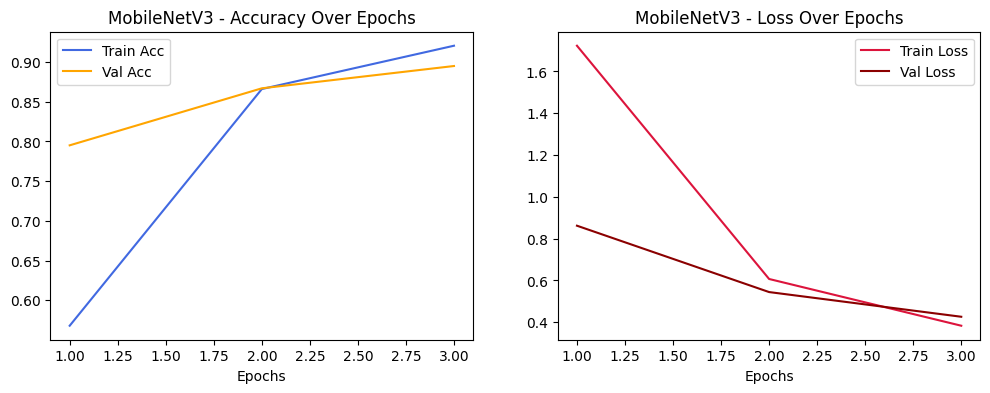

🎯 Final Evaluation Accuracy: 89.50%


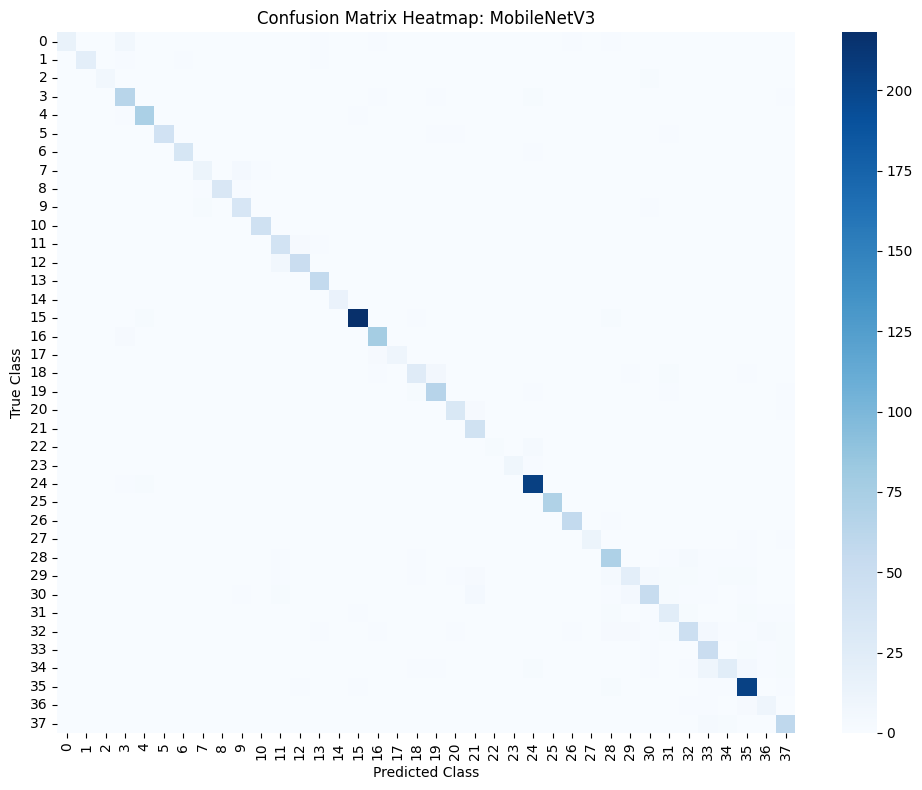

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.59      0.74        27
                                 Apple___Black_rot       1.00      0.88      0.94        25
                          Apple___Cedar_apple_rust       1.00      0.78      0.88         9
                                   Apple___healthy       0.83      0.93      0.88        69
                               Blueberry___healthy       0.95      0.97      0.96        75
          Cherry_(including_sour)___Powdery_mildew       1.00      0.93      0.97        45
                 Cherry_(including_sour)___healthy       0.97      0.97      0.97        37
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.67      0.73        18
                       Corn_(maize)___Common_rust_       1.00      0.94      0.97        36
               Corn_(maize)___Northern_Leaf_Blight       0.83      0.92      0.

In [2]:
# --- 1. EVALUATION VISUALIZATION FUNCTIONS ---
def plot_metrics(history, model_name):
    epochs_range = range(1, len(history.history['accuracy']) + 1)
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history.history['accuracy'], label='Train Acc', color='royalblue')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Val Acc', color='orange')
    plt.title(f'{model_name} - Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history.history['loss'], label='Train Loss', color='crimson')
    plt.plot(epochs_range, history.history['val_loss'], label='Val Loss', color='darkred')
    plt.title(f'{model_name} - Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.legend()
    plt.show()

def evaluate_local_model(model, history, model_name, elapsed_time):
    print(f"\n" + "="*20 + f" {model_name} PERFORMANCE BREAKDOWN " + "="*20)
    print(f"⏱️ Training Duration: {elapsed_time:.2f} seconds")
    plot_metrics(history, model_name)
    
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    print(f"🎯 Final Evaluation Accuracy: {accuracy*100:.2f}%")
    
    y_pred, y_true = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
        
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap='Blues') # Heatmap annotations off due to large class count
    plt.title(f'Confusion Matrix Heatmap: {model_name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_true, y_pred, target_names=train_ds.class_names, zero_division=0))

# --- 2. ARCHITECTURE TRAINING LOOPS ---

# MODEL 1: ResNet50
print("\n🚀 Initializing ResNet50 Pipeline...")
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_resnet.trainable = False
model_resnet = Sequential([base_resnet, GlobalAveragePooling2D(), Dense(num_classes, activation='softmax')])
model_resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
start = time.time()
history_resnet = model_resnet.fit(train_ds, validation_data=val_ds, epochs=LOCAL_EPOCHS)
time_resnet = time.time() - start
evaluate_local_model(model_resnet, history_resnet, "ResNet50", time_resnet)

# MODEL 2: DenseNet121
print("\n🚀 Initializing DenseNet121 Pipeline...")
base_dense = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_dense.trainable = False
model_dense = Sequential([base_dense, GlobalAveragePooling2D(), Dense(num_classes, activation='softmax')])
model_dense.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
start = time.time()
history_dense = model_dense.fit(train_ds, validation_data=val_ds, epochs=LOCAL_EPOCHS)
time_dense = time.time() - start
evaluate_local_model(model_dense, history_dense, "DenseNet121", time_dense)

# MODEL 3: MobileNetV3
print("\n🚀 Initializing MobileNetV3 Pipeline...")
base_mobile = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_mobile.trainable = False
model_mobile = Sequential([base_mobile, GlobalAveragePooling2D(), Dense(num_classes, activation='softmax')])
model_mobile.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
start = time.time()
history_mobile = model_mobile.fit(train_ds, validation_data=val_ds, epochs=LOCAL_EPOCHS)
time_mobile = time.time() - start
evaluate_local_model(model_mobile, history_mobile, "MobileNetV3", time_mobile)

print("\n✅ All comparative analytics, lines graphs, and matrices are completely generated!")

In [2]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Create the target folder cleanly
!mkdir -p /content/dataset

# 3. Extract the ZIP from the specific 'PlantVillage_Raw' folder
!unzip -q "/content/drive/MyDrive/PlantVillage_Raw/PlantVillage.zip" -d "/content/dataset"

# 4. Install split-folders
!pip install split-folders
import splitfolders
import os

# 5. Check what folder name was inside the zip file automatically
unzipped_contents = os.listdir('/content/dataset')
print(f"Unzipped folders found: {unzipped_contents}")

# Use the first extracted folder dynamically as the input
input_folder = os.path.join('/content/dataset', unzipped_contents[0])
output_folder = '/content/final_split_dataset'

# 6. Split into Train (80%), Val (10%), Test (10%)
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.8, .1, .1))

print("✅ Data Engineering Complete! Folders are ready.")

MessageError: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/m-s-kkb-use1b0-39opjo0u0l9wa?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_logo-15

Part 2: Data Modelling.

In [ ]:
import os

# Define the direct paths based on your unzipped folder structure
train_dir = '/content/dataset/PlantVillage/train'

# Let's verify what subfolders (classes) are inside your train directory
if os.path.exists(train_dir):
    print("✅ Found the training directory!")
    print(f"Your classes are: {os.listdir(train_dir)}")
else:
    print("❌ Directory path error. Double-check your unzipped folder names.")

In [ ]:
import tensorflow as tf
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = '/content/dataset/PlantVillage/train'

# 1. Split the folder automatically into 80% Train and 20% Validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# For evaluation requirements, we'll use a subset of validation as our test benchmark
test_ds = val_ds

num_classes = len(train_ds.class_names)
print(f"\nDetected Classes ({num_classes}): {train_ds.class_names}")

# --- MODEL 1: ResNet50 ---
print("\n🚀 Starting ResNet50 Training...")
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False
model_resnet = Sequential([base_resnet, GlobalAveragePooling2D(), Dense(num_classes, activation='softmax')])
model_resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start = time.time()
history_resnet = model_resnet.fit(train_ds, validation_data=val_ds, epochs=50)
time_resnet = time.time() - start
print(f"⌛ ResNet50 Training Finished in: {time_resnet:.2f} seconds")

# --- MODEL 2: DenseNet121 ---
print("\n🚀 Starting DenseNet121 Training...")
base_dense = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_dense.trainable = False
model_dense = Sequential([base_dense, GlobalAveragePooling2D(), Dense(num_classes, activation='softmax')])
model_dense.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start = time.time()
history_dense = model_dense.fit(train_ds, validation_data=val_ds, epochs=50)
time_dense = time.time() - start
print(f"⌛ DenseNet121 Training Finished in: {time_dense:.2f} seconds")

# --- MODEL 3: MobileNetV3 ---
print("\n🚀 Starting MobileNetV3 Training...")
base_mobile = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_mobile.trainable = False
model_mobile = Sequential([base_mobile, GlobalAveragePooling2D(), Dense(num_classes, activation='softmax')])
model_mobile.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start = time.time()
history_mobile = model_mobile.fit(train_ds, validation_data=val_ds, epochs=50)
time_mobile = time.time() - start
print(f"⌛ MobileNetV3 Training Finished in: {time_mobile:.2f} seconds")

print("\n✅ All 3 models have finished training successfully!")